In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path

# Notebook to generally study MC data provided kindly by those at IFIC (Josh Renner in particular)

In [10]:

def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)

In [14]:
path_5bar = '/gluster/data/next/files/JOSH_IFIC_MC/NEXT100/5bar/pure_xe/0nubb/nexus/out/'
path_13bar = '/gluster/data/next/files/JOSH_IFIC_MC/NEXT100/13bar/pure_xe/0nubb/nexus/out/'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 1)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 1)
display(hits_5bar)
display(pinfo_5bar)

,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,64000,-387.904449,96.874733,651.041626,0.003594,0.003358,ACTIVE,2,0
1,64000,-387.093292,96.510323,651.489929,0.007272,0.001940,ACTIVE,2,1
2,64000,-386.368622,96.199760,652.101685,0.010959,0.002565,ACTIVE,2,2
3,64000,-385.599030,95.992615,652.704651,0.014654,0.002575,ACTIVE,2,3
4,64000,-384.869476,95.640495,653.278625,0.018326,0.001866,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
744904,64999,-244.204636,309.636108,226.782700,0.718436,0.001888,ACTIVE,11,10
744905,64999,-244.213852,309.626770,226.795715,0.718782,0.003285,ACTIVE,11,11
744906,64999,-244.205383,309.623810,226.797256,0.718999,0.002143,ACTIVE,11,12
744907,64999,-244.207870,309.621338,226.794907,0.719131,0.001733,ACTIVE,11,13


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,64000,2,e-,1,0,-388.523071,97.456970,650.565979,0.000000,-349.190033,...,0.278899,-0.778668,0.691932,-0.0,0.0,-0.0,0.682315,179.135483,none,eIoni
1,64000,5,gamma,0,2,-354.453949,111.354309,672.330322,0.535153,-344.923431,...,0.021649,0.004914,-0.070246,0.0,0.0,-0.0,0.073671,32.432362,eBrem,phot
2,64000,16,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923431,...,-0.000245,0.003062,0.006001,0.0,-0.0,0.0,0.000044,0.000003,phot,msc
3,64000,15,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.003131,0.002788,0.002354,-0.0,0.0,0.0,0.000023,0.000116,phot,msc
4,64000,14,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.002072,-0.001915,0.006238,0.0,-0.0,0.0,0.000046,0.000370,phot,msc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36939,64999,20,e-,0,15,-222.487579,337.452423,214.628113,1.084701,-222.488312,...,-0.022668,-0.006121,-0.000871,-0.0,-0.0,0.0,0.000540,0.002943,phot,eIoni
36940,64999,19,e-,0,15,-222.487579,337.452423,214.628113,1.084701,-222.490524,...,-0.035439,-0.015493,0.044853,-0.0,0.0,-0.0,0.003421,0.033871,phot,eIoni
36941,64999,14,e-,0,13,-221.723022,336.323608,214.220367,1.079954,-221.729416,...,-0.056139,-0.075544,-0.049184,-0.0,-0.0,0.0,0.010918,0.159957,phot,eIoni
36942,64999,12,e-,0,1,-220.419846,341.183136,212.816788,1.036682,-219.356094,...,0.295386,0.059588,-0.227795,-0.0,0.0,-0.0,0.124465,13.927027,eIoni,eIoni


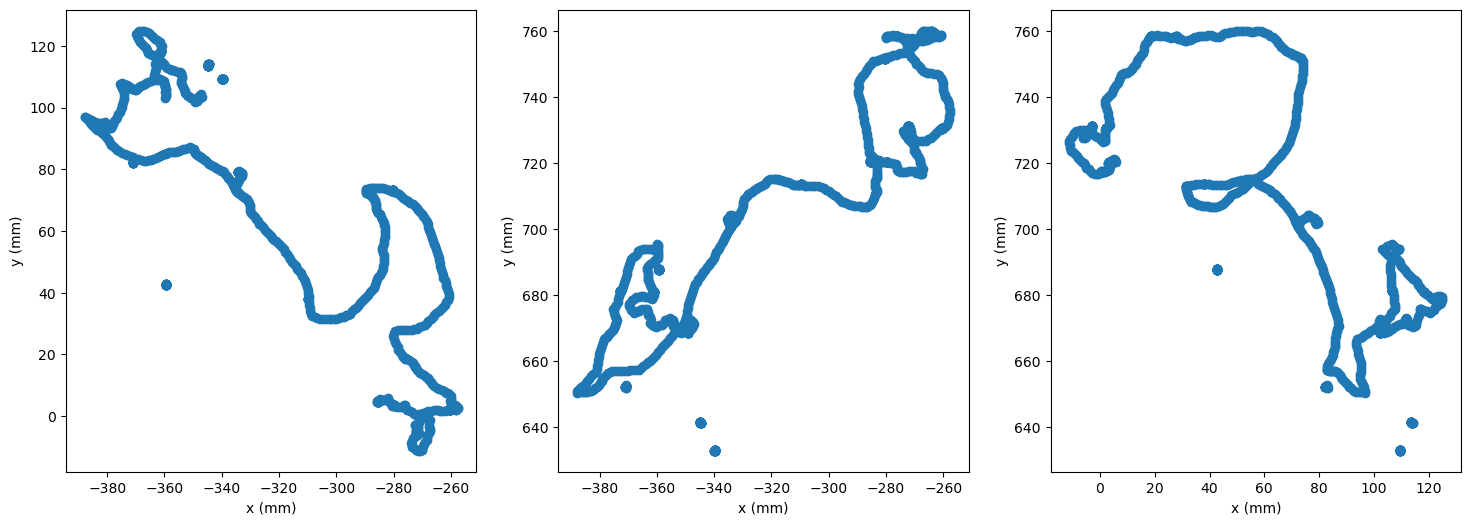

Space between hits:
0.018387815 -0.015103827 0.0016505464
0.018387815 -0.015103827 0.0016505464


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,64000,2,e-,1,0,-388.523071,97.456970,650.565979,0.000000,-349.190033,...,0.278899,-0.778668,0.691932,-0.0,0.0,-0.0,0.682315,179.135483,none,eIoni
1,64000,5,gamma,0,2,-354.453949,111.354309,672.330322,0.535153,-344.923431,...,0.021649,0.004914,-0.070246,0.0,0.0,-0.0,0.073671,32.432362,eBrem,phot
2,64000,16,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923431,...,-0.000245,0.003062,0.006001,0.0,-0.0,0.0,0.000044,0.000003,phot,msc
3,64000,15,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.003131,0.002788,0.002354,-0.0,0.0,0.0,0.000023,0.000116,phot,msc
4,64000,14,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.002072,-0.001915,0.006238,0.0,-0.0,0.0,0.000046,0.000370,phot,msc
5,64000,13,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923492,...,-0.004362,-0.005224,-0.000742,0.0,-0.0,0.0,0.000046,0.000109,phot,msc
6,64000,12,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923431,...,-0.000094,0.001195,-0.003025,0.0,-0.0,-0.0,0.000010,0.000245,phot,msc
7,64000,11,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.922791,...,0.018526,0.014516,0.000504,0.0,0.0,0.0,0.000542,0.003096,phot,eIoni
8,64000,10,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.005862,-0.001094,0.003364,0.0,-0.0,0.0,0.000046,0.000073,phot,msc
9,64000,9,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.924042,...,-0.007948,-0.005686,-0.002792,-0.0,-0.0,0.0,0.000101,0.000863,phot,eIoni


In [28]:
# Lets look at them quickly, extract some info
for evt, df in hits_5bar.groupby('event_id'):
    fig, axes = plt.subplots(1,3, figsize=(18,6))
    axes[0].scatter(df.x, df.y)
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    
    axes[1].scatter(df.x, df.z)
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    
    axes[2].scatter(df.y, df.z)
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    plt.show()
    
    print('Space between hits:')
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    print(np.average(np.diff(df.x.values)), np.average(np.diff(df.y.values)), np.average(np.diff(df.z.values)))
    break

    
    
for evt, df in pinfo_5bar.groupby('event_id'):
    display(df)
    break

In [33]:
def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits

def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

## clusterise

In [61]:
tagged_hits_5bar = cluster_tagger(hits_5bar, min_samples = 5, scale_xy = 2, scale_z = 2)

Event: 64000, Cluster: 0
Event: 64000, Cluster: 1
Event: 64000, Cluster: 2
Event: 64000, Cluster: 3
Event: 64000, Cluster: 4


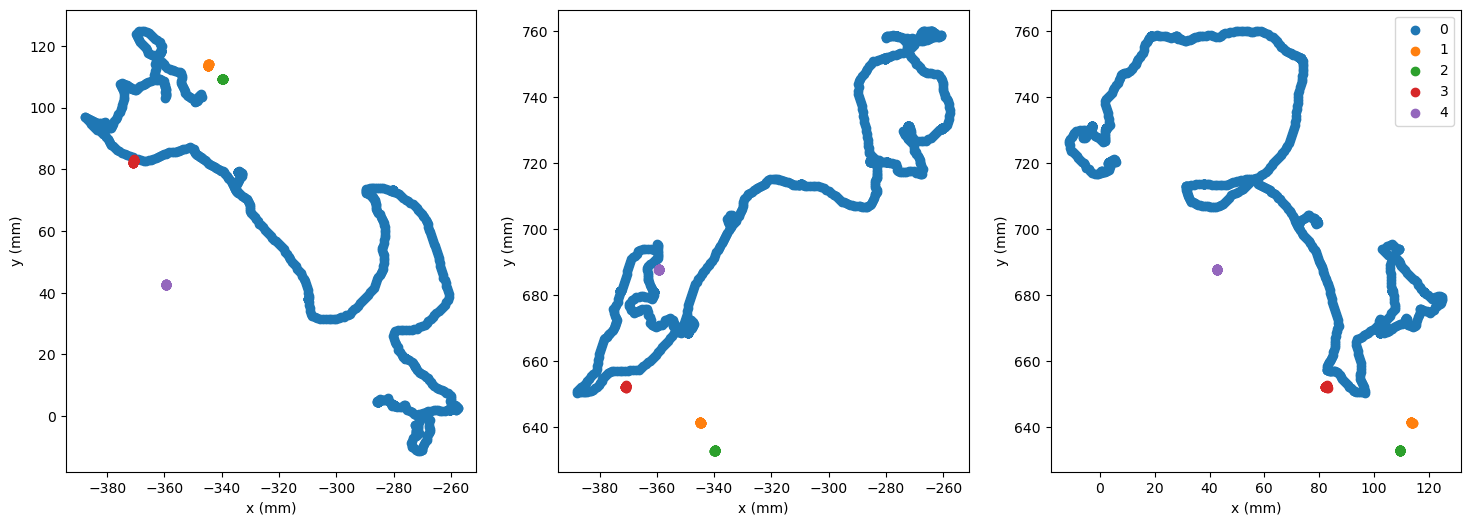

In [62]:
first_event = None

colors = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

fig, axes = plt.subplots(1,3, figsize=(18,6))
for (event, cluster), df in tagged_hits_5bar.groupby(['event_id', 'cluster']):
    
    colours = next(colors)
    if first_event is None:
        first_event = event
    if event != first_event:
        break
    
    if cluster == -1:
        continue
    print(f'Event: {event}, Cluster: {cluster}')
    #print(df)
    
    
    axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
    axes[0].set_xlabel('x (mm)')
    axes[0].set_ylabel('y (mm)')
    
    axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
    axes[1].set_xlabel('x (mm)')
    axes[1].set_ylabel('y (mm)')
    
    axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
    axes[2].set_xlabel('x (mm)')
    axes[2].set_ylabel('y (mm)')
    
    axes[2].legend()
    
plt.show()


## take the biggest cluster, find the maximal distance between the points to collect length

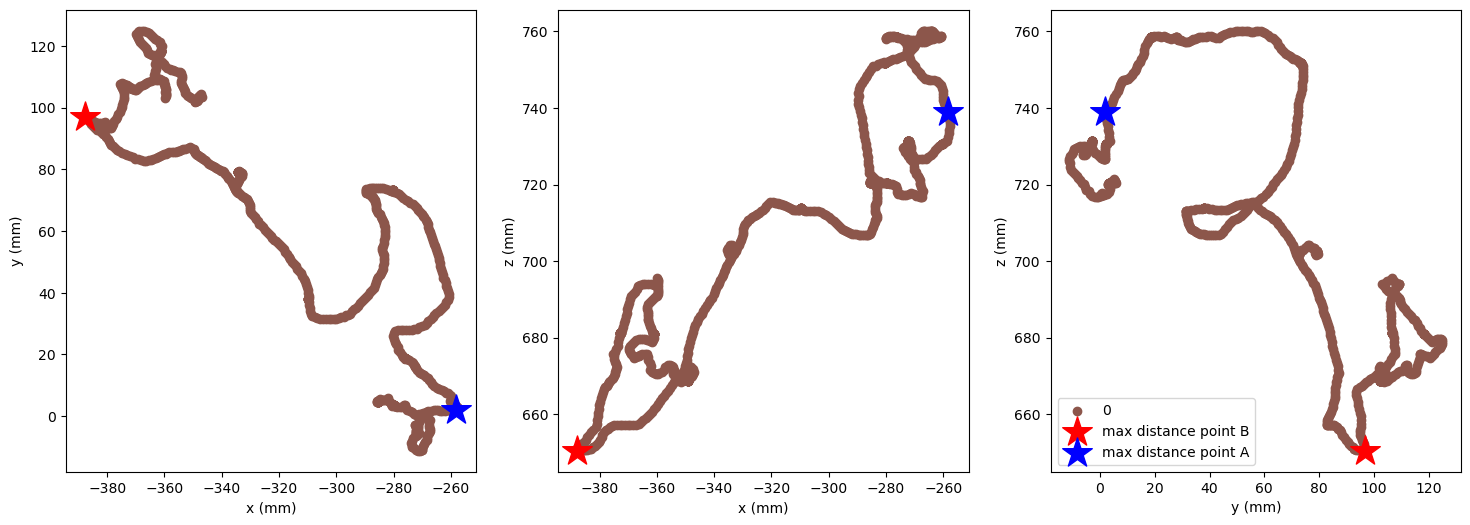

evt 64000 max distance 183.293328174676mm
maximal positions: x   -387.770020
y     96.815491
z    650.456726
Name: 277, dtype: float32, x   -258.287933
y      1.847761
z    738.842041
Name: 632, dtype: float32


In [100]:
for evt, df in tagged_hits_5bar.groupby('event_id'):
    # check if event has one track larger than 100. If so, include
    if (df.cluster.value_counts() > 100).sum() == 1:
        dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
        df = df[df['cluster'] == dominant_cluster]
        
        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        max_dist = dists[idx]
        pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        
        
        fig, axes = plt.subplots(1,3, figsize=(18,6))
        axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
        axes[0].set_xlabel('x (mm)')
        axes[0].set_ylabel('y (mm)')
    
        axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
        axes[1].set_xlabel('x (mm)')
        axes[1].set_ylabel('z (mm)')
    
        axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
        axes[2].set_xlabel('y (mm)')
        axes[2].set_ylabel('z (mm)')
    
        
        
        axes[0].scatter(pos_a.x, pos_a.y, marker='*', color='red', s=500)
        axes[1].scatter(pos_a.x, pos_a.z, marker='*', color='red', s=500)
        axes[2].scatter(pos_a.y, pos_a.z, marker='*', color='red', s=500, label = 'max distance point B')
        
        axes[0].scatter(pos_b.x, pos_b.y, marker='*', color='blue', s=500)
        axes[1].scatter(pos_b.x, pos_b.z, marker='*', color='blue', s=500)
        axes[2].scatter(pos_b.y, pos_b.z, marker='*', color='blue', s=500, label = 'max distance point A')
        
        axes[2].legend()
        plt.show()
        print(f'evt {evt} max distance {max_dist}mm')
        print(f'maximal positions: {pos_a}, {pos_b}')
    break

,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
0,64000,-387.904449,96.874733,651.041626,0.003594,0.003358,ACTIVE,2,0,0
1,64000,-387.093292,96.510323,651.489929,0.007272,0.001940,ACTIVE,2,1,0
2,64000,-386.368622,96.199760,652.101685,0.010959,0.002565,ACTIVE,2,2,0
3,64000,-385.599030,95.992615,652.704651,0.014654,0.002575,ACTIVE,2,3,0
4,64000,-384.869476,95.640495,653.278625,0.018326,0.001866,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
881,64000,-334.248260,78.980904,702.537354,0.408988,0.000201,ACTIVE,31,38,0
882,64000,-334.249603,78.978844,702.547791,0.409230,0.001485,ACTIVE,31,39,0
883,64000,-334.250824,78.981804,702.553955,0.409413,0.001383,ACTIVE,31,40,0
884,64000,-334.252258,78.985123,702.555664,0.409540,0.002060,ACTIVE,31,41,0


64000


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,64000,2,e-,1,0,-388.523071,97.45697,650.565979,0.0,-349.190033,...,0.278899,-0.778668,0.691932,-0.0,0.0,-0.0,0.682315,179.135483,none,eIoni
28,64000,1,e-,1,0,-388.523071,97.45697,650.565979,0.0,-285.291840,...,1.780798,-1.311746,-0.274055,-0.0,-0.0,0.0,1.775515,445.111023,none,eIoni


624.2465

[ 2  4  3  1 37 36 35 34 33 32 43 42 41 40 39 38 31]


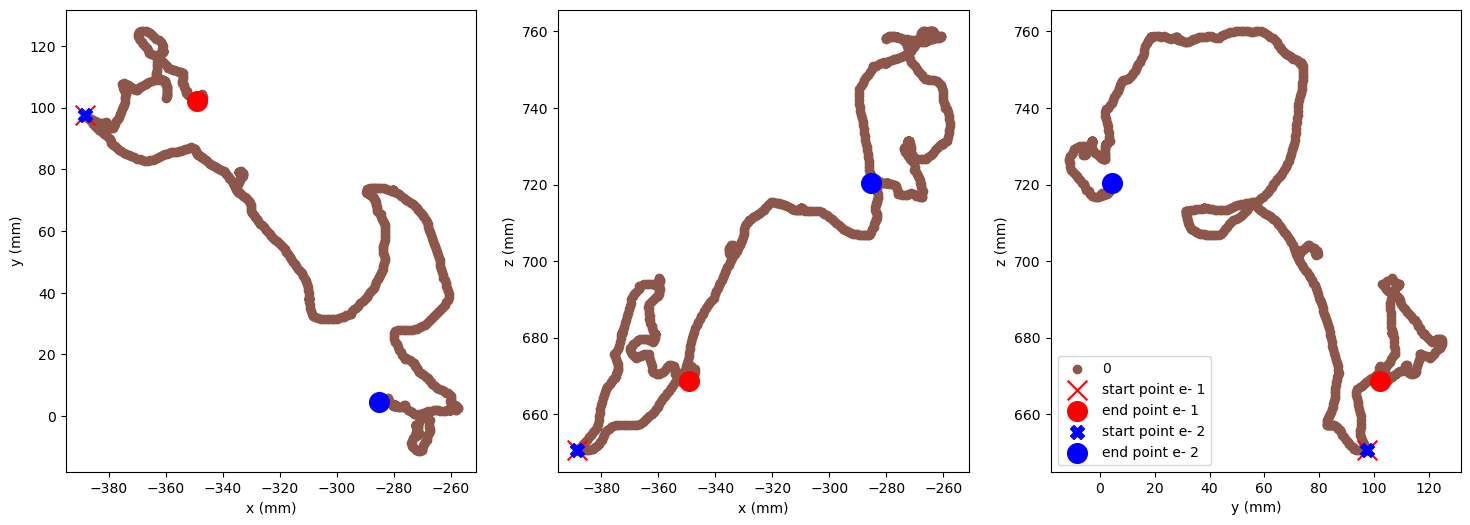

In [125]:
## and length via true particle information

display(df)
print(df.event_id.unique()[0])
mask = (pinfo_5bar.event_id == df.event_id.unique()[0]) & (pinfo_5bar.creator_proc == 'none')
nubb0_pid = pinfo_5bar[mask]

display(nubb0_pid)
display(nubb0_pid.length.sum())
print(df.particle_id.unique())


fig, axes = plt.subplots(1,3, figsize=(18,6))
axes[0].scatter(df.x, df.y, label = f'{cluster}', color = colours)
axes[0].set_xlabel('x (mm)')
axes[0].set_ylabel('y (mm)')

axes[1].scatter(df.x, df.z, label = f'{cluster}', color = colours)
axes[1].set_xlabel('x (mm)')
axes[1].set_ylabel('z (mm)')

axes[2].scatter(df.y, df.z, label = f'{cluster}', color = colours)
axes[2].set_xlabel('y (mm)')
axes[2].set_ylabel('z (mm)')



axes[0].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_y, marker='x', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].initial_x, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].initial_y, nubb0_pid.iloc[0].initial_z, marker='x', color='red', s=200, label = 'start point e- 1')

axes[0].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, marker='o', color='red', s=200)
axes[1].scatter(nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200)
axes[2].scatter(nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z, marker='o', color='red', s=200, label = 'end point e- 1')


axes[0].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_y, marker='X', color='blue', s=100)
axes[1].scatter(nubb0_pid.iloc[1].initial_x, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100)
axes[2].scatter(nubb0_pid.iloc[1].initial_y, nubb0_pid.iloc[1].initial_z, marker='X', color='blue', s=100, label = 'start point e- 2')

axes[0].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, marker='o', color='blue', s=200)
axes[1].scatter(nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200)
axes[2].scatter(nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z, marker='o', color='blue', s=200, label = 'end point e- 2')


axes[2].legend()
plt.show()


[-349.19003, 102.11135, 668.59235]


,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
0,64000,-387.904449,96.874733,651.041626,0.003594,0.003358,ACTIVE,2,0,0
1,64000,-387.093292,96.510323,651.489929,0.007272,0.001940,ACTIVE,2,1,0
2,64000,-386.368622,96.199760,652.101685,0.010959,0.002565,ACTIVE,2,2,0
3,64000,-385.599030,95.992615,652.704651,0.014654,0.002575,ACTIVE,2,3,0
4,64000,-384.869476,95.640495,653.278625,0.018326,0.001866,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
881,64000,-334.248260,78.980904,702.537354,0.408988,0.000201,ACTIVE,31,38,0
882,64000,-334.249603,78.978844,702.547791,0.409230,0.001485,ACTIVE,31,39,0
883,64000,-334.250824,78.981804,702.553955,0.409413,0.001383,ACTIVE,31,40,0
884,64000,-334.252258,78.985123,702.555664,0.409540,0.002060,ACTIVE,31,41,0


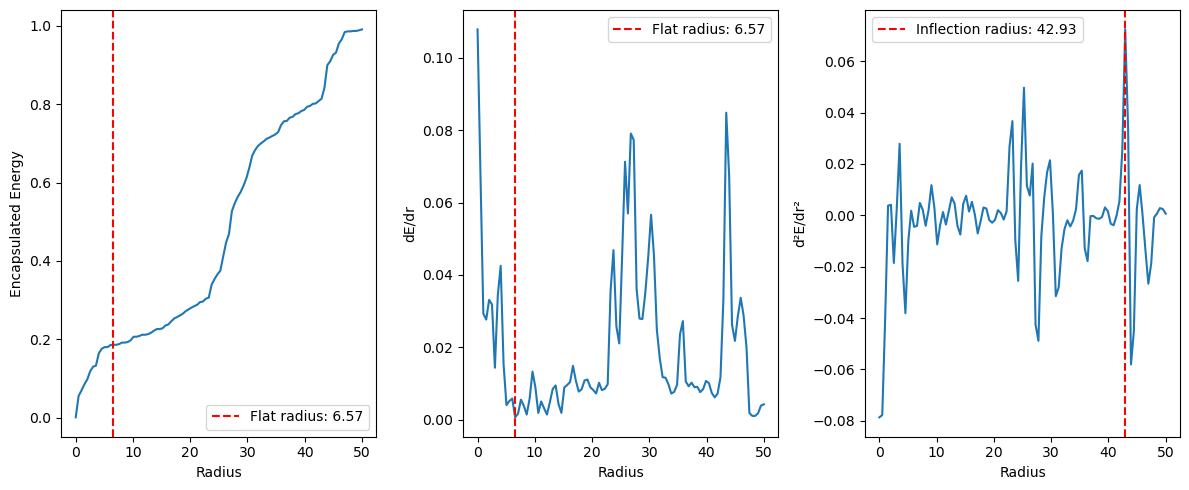

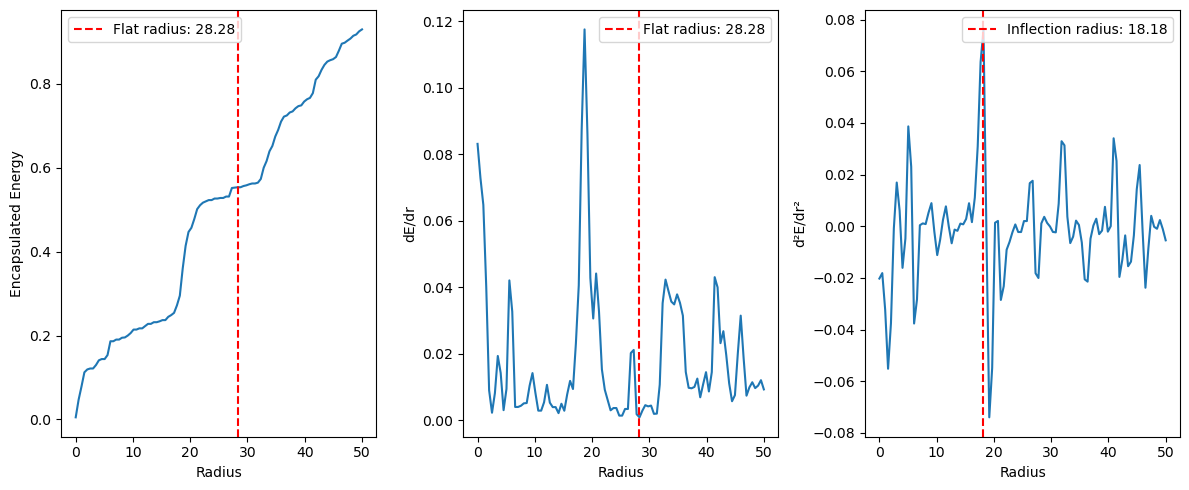

In [135]:
# extract blob energy by going to final points of the track, 
# calculating the energy around the final point radially, 
# and taking the derivative of that and choosing when the gradient does something funky

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]
print(point)
# hits belonging to the cluster
display(df)

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    
    energies = [df[dists <= r]['energy'].sum() for r in radii]
    return np.array(energies)


radii    = np.linspace(0, 50, 100)
energies_1 = encapsulated_energy(df, point_1, radii)
energies_2 = encapsulated_energy(df, point_2, radii)

# derivative
dE_dr_1 = np.gradient(energies_1, radii)
dE_dr_2 = np.gradient(energies_2, radii)

# find where it flattens — below some threshold
threshold_1   = 0.01 * dE_dr_1.max()  # 1% of peak derivative
flat_idx_1    = np.argmax(dE_dr_1 < threshold)
flat_radius_1 = radii[flat_idx_1]

threshold_2   = 0.01 * dE_dr_2.max()  # 1% of peak derivative
flat_idx_2    = np.argmax(dE_dr_2 < threshold)
flat_radius_2 = radii[flat_idx_2]


# find second derivative
d2E_dr2_1     = np.gradient(dE_dr_1, radii)
inflect_idx_1  = np.argmax(d2E_dr2_1)
inflect_radius_1 = radii[inflect_idx_1]

# find second derivative
d2E_dr2_2     = np.gradient(dE_dr_2, radii)
inflect_idx_2  = np.argmax(d2E_dr2_2)
inflect_radius_2 = radii[inflect_idx_2]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_1)
axes[0].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_1)
axes[1].axvline(flat_radius_1, color='red', linestyle='--', label=f'Flat radius: {flat_radius_1:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_1)
axes[2].axvline(inflect_radius_1, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_1:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].plot(radii, energies_2)
axes[0].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[0].set_xlabel('Radius')
axes[0].set_ylabel('Encapsulated Energy')
axes[0].legend()

axes[1].plot(radii, dE_dr_2)
axes[1].axvline(flat_radius_2, color='red', linestyle='--', label=f'Flat radius: {flat_radius_2:.2f}')
axes[1].set_xlabel('Radius')
axes[1].set_ylabel('dE/dr')
axes[1].legend()

axes[2].plot(radii, d2E_dr2_2)
axes[2].axvline(inflect_radius_2, color='red', linestyle='--', label=f'Inflection radius: {inflect_radius_2:.2f}')
axes[2].set_xlabel('Radius')
axes[2].set_ylabel('d²E/dr²')
axes[2].legend()

plt.tight_layout()
plt.show()

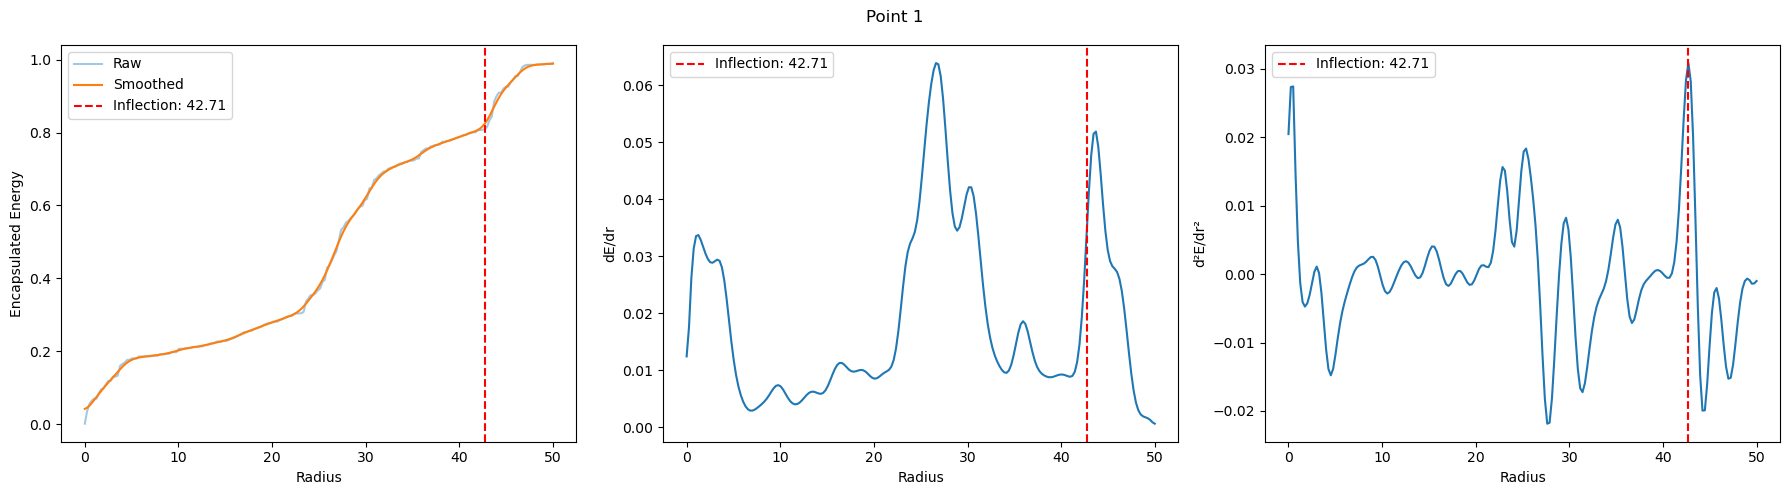

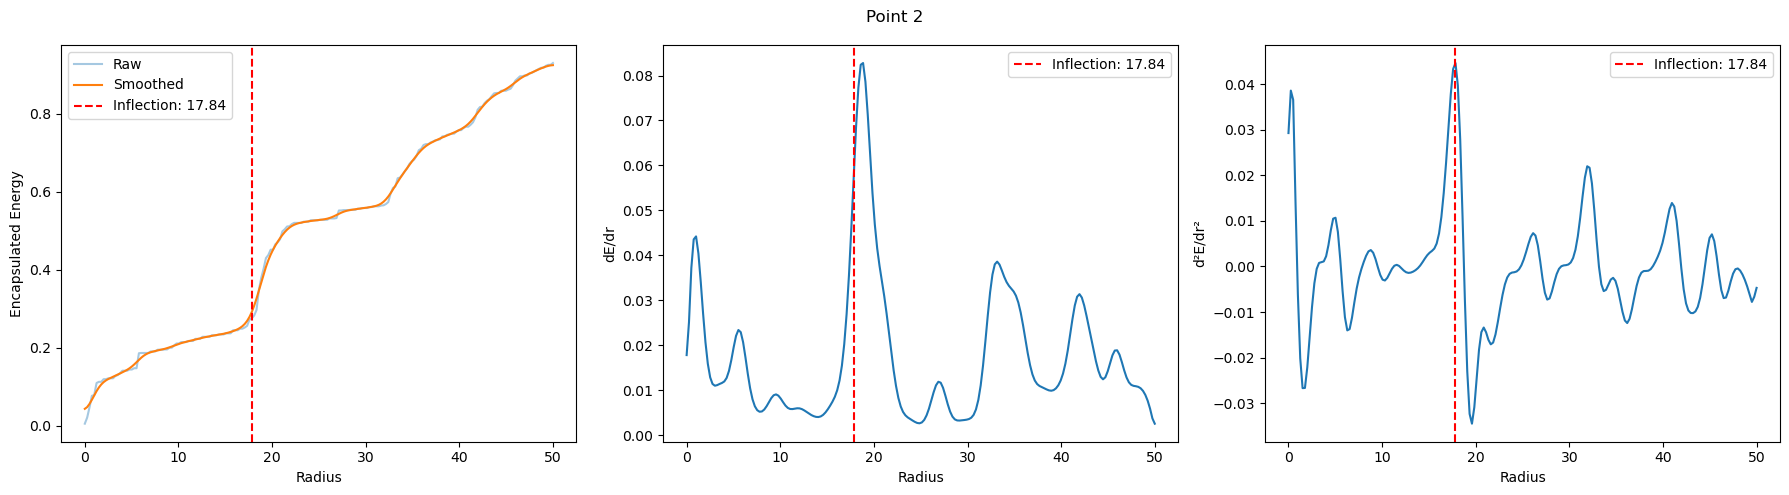

Point 1 blob energy: 0.8240
Point 2 blob energy: 0.2919


In [146]:
from scipy.ndimage import gaussian_filter1d

def encapsulated_energy(df, point, radii):
    coords = df[['x', 'y', 'z']].to_numpy()
    dists  = cdist([point], coords).flatten()
    return np.array([df[dists <= r]['energy'].sum() for r in radii])

def blob_energy_analysis(df, point, radii, sigma=5):
    energies        = encapsulated_energy(df, point, radii)
    energies_smooth = gaussian_filter1d(energies, sigma=sigma)
    dE_dr           = np.gradient(energies_smooth, radii)
    d2E_dr2         = np.gradient(dE_dr, radii)
    inflect_idx     = np.argmax(d2E_dr2)
    inflect_radius  = radii[inflect_idx]
    inflect_energy  = energies_smooth[inflect_idx]
    return energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, inflect_energy

def plot_blob_analysis(radii, energies, energies_smooth, dE_dr, d2E_dr2, inflect_radius, label=''):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(label)

    axes[0].plot(radii, energies,        alpha=0.4, label='Raw')
    axes[0].plot(radii, energies_smooth, label='Smoothed')
    axes[0].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[0].set_xlabel('Radius')
    axes[0].set_ylabel('Encapsulated Energy')
    axes[0].legend()

    axes[1].plot(radii, dE_dr)
    axes[1].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[1].set_xlabel('Radius')
    axes[1].set_ylabel('dE/dr')
    axes[1].legend()

    axes[2].plot(radii, d2E_dr2)
    axes[2].axvline(inflect_radius, color='red', linestyle='--', label=f'Inflection: {inflect_radius:.2f}')
    axes[2].set_xlabel('Radius')
    axes[2].set_ylabel('d²E/dr²')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# points
point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii  = np.linspace(0, 50, 200)
sigma  = 3

results_1 = blob_energy_analysis(df, point_1, radii, sigma=sigma)
results_2 = blob_energy_analysis(df, point_2, radii, sigma=sigma)

energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, inflect_energy_1 = results_1
energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, inflect_energy_2 = results_2

plot_blob_analysis(radii, energies_1, energies_smooth_1, dE_dr_1, d2E_dr2_1, inflect_radius_1, label='Point 1')
plot_blob_analysis(radii, energies_2, energies_smooth_2, dE_dr_2, d2E_dr2_2, inflect_radius_2, label='Point 2')

print(f'Point 1 blob energy: {inflect_energy_1:.4f}')
print(f'Point 2 blob energy: {inflect_energy_2:.4f}')

In [156]:
def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]

point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

radii     = np.linspace(0, 50, 200)
threshold = 0.5  # MeV

blob_e_1 = blob_energy(df, point_1, radii, threshold)
blob_e_2 = blob_energy(df, point_2, radii, threshold)


blob_r_1 = blob_radius(df, point_1, radii, threshold)
blob_r_2 = blob_radius(df, point_2, radii, threshold)

print(f'Point 1 blob energy: {blob_e_1:.4f}\nPoint 1 blob radius: {blob_r_1:.4f}\n')
print(f'Point 2 blob energy: {blob_e_2:.4f}\nPoint 2 blob radius: {blob_r_2:.4f}\n')

Point 1 blob energy: 0.5040
Point 1 blob radius: 27.1357

Point 2 blob energy: 0.5037
Point 2 blob radius: 21.3568



In [127]:
# how to quantify entanglement?
# naive start: take true length and maximum distance between hits as a ratio.

true_length = nubb0_pid.length.sum()
entanglement = (max_dist / true_length)
print(f'Entanglement: {entanglement*100:.2f}%')


Entanglement: 29.36%


In [152]:
display(df)

,event_id,x,y,z,time,energy,label,particle_id,hit_id,cluster
0,64000,-387.904449,96.874733,651.041626,0.003594,0.003358,ACTIVE,2,0,0
1,64000,-387.093292,96.510323,651.489929,0.007272,0.001940,ACTIVE,2,1,0
2,64000,-386.368622,96.199760,652.101685,0.010959,0.002565,ACTIVE,2,2,0
3,64000,-385.599030,95.992615,652.704651,0.014654,0.002575,ACTIVE,2,3,0
4,64000,-384.869476,95.640495,653.278625,0.018326,0.001866,ACTIVE,2,4,0
...,...,...,...,...,...,...,...,...,...,...
881,64000,-334.248260,78.980904,702.537354,0.408988,0.000201,ACTIVE,31,38,0
882,64000,-334.249603,78.978844,702.547791,0.409230,0.001485,ACTIVE,31,39,0
883,64000,-334.250824,78.981804,702.553955,0.409413,0.001383,ACTIVE,31,40,0
884,64000,-334.252258,78.985123,702.555664,0.409540,0.002060,ACTIVE,31,41,0


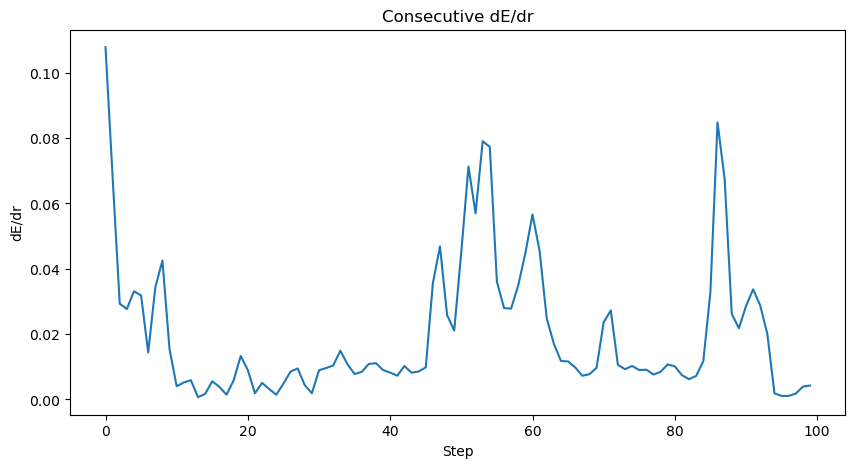

Median dE/dr: 9.374893039648668e-08


In [151]:
# hit energy density is simple
def dE_dr_consecutive(df):
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists

de_dr = dE_dr_consecutive(df)
plt.figure(figsize=(10, 5))
plt.plot(dE_dr)
plt.xlabel('Step')
plt.ylabel('dE/dr')
plt.title('Consecutive dE/dr')
plt.show()

print(f'Median dE/dr: {np.median(de_dr)}')

In [161]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.cluster import DBSCAN
from scipy.spatial.distance import pdist, cdist

from pathlib import Path



def load_h5_files(folder, key, slices = None):
    files = list(Path(folder).glob("*.h5"))[:slices]
    return pd.concat([pd.read_hdf(f, key) for f in files], ignore_index = True)


# hit energy density is simple
def dE_dr_consecutive(df):
    coords   = df[['x', 'y', 'z']].to_numpy()
    energies = df['energy'].to_numpy()
    
    dists = np.sqrt(np.sum(np.diff(coords, axis=0)**2, axis=1))
    dE    = np.diff(energies)
    
    return dE / dists


def blob_radius(df, point, radii, threshold):
    coords   = df[['x', 'y', 'z']].to_numpy()
    dists    = cdist([point], coords).flatten()
    energies = np.array([df[dists <= r]['energy'].sum() for r in radii])
    idx      = np.argmax(energies >= threshold)
    return radii[idx]


def tag_hits_in_event(event_hits   : pd.DataFrame
                     , *
                     , min_samples : int
                     , scale_xy    : float
                     , scale_z     : float
                     ) -> pd.DataFrame:
    """
    Applies DBSCAN clustering to a DataFrame containing hits from a single event.
    Hits coordinates are scaled to account for the anisotropy of the detector geometry.
    A 'cluster' column is added to the group with the resulting labels.

    Parameters
    ----------
    event_hits  : pd.DataFrame
        DataFrame with hits from a single event. Must contain 'X', 'Y', 'Z' columns.
    min_samples : int
        Minimum number of samples required to form a dense region (cluster).
        This includes the point itself.
    scale_xy    : float
        Scaling factor to apply to the XY coordinates before clustering.
    scale_z     : float
        Scaling factor to apply to the Z coordinate before clustering.

    Returns
    -------
    pd.DataFrame
        The input DataFrame with a 'cluster' column added.
    """
    coords = event_hits[['x', 'y', 'z']].to_numpy()
    # A proper scaling leads to hits being separeted 
    # by a distance of 1 in the DBSCAN metric space
    coords[:, :2] /= scale_xy
    coords[:, 2]  /= scale_z

    # eps parameter is fixed to a value a bit higher of √3
    # to retain diagonal neighbours in the same cluster
    labels = DBSCAN(eps=1.8, min_samples=min_samples).fit_predict(coords)
    event_hits['cluster'] = labels

    return event_hits


def cluster_tagger(df_hits      : pd.DataFrame
                  , *
                  , min_samples : int
                  , scale_xy    : float
                  , scale_z     : float
                  ) -> pd.DataFrame:
    """
    This function groups the input DataFrame by 'event' and applies the
    `tag_hits_in_event` function to each event's group of hits.

    Parameters
    ----------
    df_hits : pd.DataFrame
        DataFrame with hit information. Must contain 'X', 'Y', 'Z', and 'event'.
    min_samples, scale_xy, scale_z : 
        See `tag_hits_in_event`
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame with an added 'cluster' column indicating the
        cluster label for each hit (-1 for noise).
    """
    if df_hits.empty:
        return df_hits.assign(cluster=pd.Series(dtype=int))

    df_clustered = df_hits.groupby('event_id', as_index=False, group_keys=False) \
                          .apply( tag_hits_in_event
                                , min_samples = min_samples
                                , scale_xy    = scale_xy
                                , scale_z     = scale_z )
    
    return df_clustered.set_index(df_hits.index)
    

def extract_topological_info(hits_df, pinfo_df, radial_threshold = 0.4):
    '''
    Extract entanglement, preferred blob radius 
    radial_threshold in MeV
    '''
    true_lengths   = [] # what the MC particle info gives, end to end
    max_extents    = [] # what are the two furthest apart hits in the track
    entanglements  = [] # max_extents / true_lengths, simply
    blob_1_size    = []
    blob_2_size    = []
    de_drs         = []
    
    # cluster tracks, extract the largest (assuming this is a 0nubb track)
    tagged_hits = cluster_tagger(hits_df, min_samples = 5, scale_xy = 2, scale_z = 2)
    
    for evt, df in tqdm(tagged_hits.groupby('event_id'), total=tagged_hits['event_id'].nunique()):
        # check if event has one track larger than 100. If so, include
        if (df.cluster.value_counts() > 100).sum() == 1:
            dominant_cluster = df['cluster'].value_counts()[df['cluster'].value_counts() > 100].index[0]
            df = df[df['cluster'] == dominant_cluster]
        else:
            continue
            
        ############################################################
        # max extent of track (furthest two hits apart)
        ############################################################

        coords = df[['x', 'y', 'z']].to_numpy()
        dists  = cdist(coords, coords)
        idx    = np.unravel_index(dists.argmax(), dists.shape)

        #pos_a    = df[['x', 'y', 'z']].iloc[idx[0]]
        #pos_b    = df[['x', 'y', 'z']].iloc[idx[1]]
        max_dist = dists[idx]
        max_extents.append(max_dist)
        
        ############################################################
        # true length of track
        ############################################################
        
        # create mask for specific event
        mask = (pinfo_df.event_id == df.event_id.unique()[0]) & (pinfo_df.creator_proc == 'none')
        nubb0_pid = pinfo_df[mask]
        
        # if it has only two elements, you've done it correctly. If not, something odd has happened.
        # this is because 0nubb is not given a process in MC particle info (lmao)
        if len(nubb0_pid) != 2:
            print(f"More than 2 events explicitly from 0nubb! You've messed up!\ndf: {nubb0_pid}")
            continue
        
        true_length = nubb0_pid.length.sum()
        true_lengths.append(nubb0_pid.length.sum())
        
        ############################################################
        # entanglement
        ############################################################
        entanglement = (max_dist / true_length)
        entanglements.append(entanglement)
        
        ############################################################
        # blob size
        ############################################################
        point_1 = [nubb0_pid.iloc[0].final_x, nubb0_pid.iloc[0].final_y, nubb0_pid.iloc[0].final_z]
        point_2 = [nubb0_pid.iloc[1].final_x, nubb0_pid.iloc[1].final_y, nubb0_pid.iloc[1].final_z]

        radii     = np.linspace(0, 50, 200)
        
        blob_r_1 = blob_radius(df, point_1, radii, threshold)
        blob_r_2 = blob_radius(df, point_2, radii, threshold)
        
        blob_1_size.append(blob_r_1)
        blob_2_size.append(blob_r_2)
    
        ############################################################
        # dE/dr
        ############################################################
        de_dr = dE_dr_consecutive(df)
        de_drs.append(np.median(de_dr))
    
    return dict(
                max_extent   = max_extents,
                true_length  = true_lengths,
                entanglement = entanglements,
                blob_1_size  = blob_1_size,
                blob_2_size  = blob_2_size,
                de_dr        = de_drs)

In [194]:
path_5bar = '/gluster/data/next/files/JOSH_IFIC_MC/NEXT100/5bar/pure_xe/0nubb/nexus/out/'

hits_5bar  = load_h5_files(path_5bar, 'MC/hits', 5)
pinfo_5bar = load_h5_files(path_5bar, 'MC/particles', 5)
display(hits_5bar)
display(pinfo_5bar)


,event_id,x,y,z,time,energy,label,particle_id,hit_id
0,64000,-387.904449,96.874733,651.041626,0.003594,0.003358,ACTIVE,2,0
1,64000,-387.093292,96.510323,651.489929,0.007272,0.001940,ACTIVE,2,1
2,64000,-386.368622,96.199760,652.101685,0.010959,0.002565,ACTIVE,2,2
3,64000,-385.599030,95.992615,652.704651,0.014654,0.002575,ACTIVE,2,3
4,64000,-384.869476,95.640495,653.278625,0.018326,0.001866,ACTIVE,2,4
...,...,...,...,...,...,...,...,...,...
3728926,73999,-228.568710,-100.743866,1219.432007,1.387936,0.002583,BUFFER,30,5
3728927,73999,-228.566757,-100.756340,1219.438843,1.388228,0.001658,BUFFER,30,6
3728928,73999,-228.565933,-100.746651,1219.437866,1.388456,0.002081,BUFFER,30,7
3728929,73999,-228.563751,-100.746513,1219.433472,1.388601,0.002204,BUFFER,30,8


,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,64000,2,e-,1,0,-388.523071,97.456970,650.565979,0.000000,-349.190033,...,0.278899,-0.778668,0.691932,-0.0,0.0,-0.0,0.682315,179.135483,none,eIoni
1,64000,5,gamma,0,2,-354.453949,111.354309,672.330322,0.535153,-344.923431,...,0.021649,0.004914,-0.070246,0.0,0.0,-0.0,0.073671,32.432362,eBrem,phot
2,64000,16,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923431,...,-0.000245,0.003062,0.006001,0.0,-0.0,0.0,0.000044,0.000003,phot,msc
3,64000,15,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.003131,0.002788,0.002354,-0.0,0.0,0.0,0.000023,0.000116,phot,msc
4,64000,14,e-,0,5,-344.923431,113.517632,641.405457,0.643336,-344.923370,...,0.002072,-0.001915,0.006238,0.0,-0.0,0.0,0.000046,0.000370,phot,msc
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185805,73999,42,e-,0,14,-231.807480,-221.514481,1121.881714,0.710884,-231.684296,...,-0.096292,0.122369,0.045427,-0.0,-0.0,0.0,0.025126,0.429051,eIoni,eIoni
185806,73999,13,e-,0,1,-235.390854,-219.441437,1152.390137,0.446337,-235.984299,...,-0.195662,0.030914,0.101491,-0.0,0.0,0.0,0.046370,3.145563,eIoni,eIoni
185807,73999,12,e-,0,1,-234.519165,-219.180801,1153.052246,0.442296,-233.499084,...,0.066548,-0.294562,-0.060026,0.0,-0.0,-0.0,0.085590,8.632182,eIoni,eIoni
185808,73999,11,e-,0,1,-212.542038,-189.162018,1142.212891,0.245264,-212.689774,...,-0.118769,0.106010,-0.065506,-0.0,0.0,-0.0,0.028218,1.292970,eIoni,eIoni


In [195]:
dict_5bar = extract_topological_info(hits_5bar, pinfo_5bar)

  0%|          | 17/5000 [00:02<10:40,  7.78it/s]/tmp/ipykernel_936264/3799128352.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
  2%|▏         | 80/5000 [00:09<09:12,  8.90it/s]/tmp/ipykernel_936264/3799128352.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [10:00<00:00,  8.32it/s]


In [196]:
# 13 bar
path_13bar = '/gluster/data/next/files/JOSH_IFIC_MC/NEXT100/13bar/0nubb/nexus/out/'

hits_13bar  = load_h5_files(path_13bar, 'MC/hits', 5)
pinfo_13bar = load_h5_files(path_13bar, 'MC/particles', 5)

In [197]:
dict_13bar = extract_topological_info(hits_13bar, pinfo_13bar)

  0%|          | 3/5000 [00:00<12:48,  6.50it/s]/tmp/ipykernel_936264/3799128352.py:28: RuntimeWarning: divide by zero encountered in divide
  return dE / dists
  5%|▌         | 251/5000 [00:30<09:15,  8.54it/s]/tmp/ipykernel_936264/3799128352.py:28: RuntimeWarning: invalid value encountered in divide
  return dE / dists
100%|██████████| 5000/5000 [09:46<00:00,  8.53it/s]


In [27]:
def print_histos(dct_5b, dct_13b, key, histo_label, bins=50, abs=False):
    if abs:
        arr_5b  = np.abs(np.array(dct_5b[key],  dtype=float))
        arr_13b = np.abs(np.array(dct_13b[key], dtype=float))
    else:
        arr_5b  = np.array(dct_5b[key],  dtype=float)
        arr_13b = np.array(dct_13b[key], dtype=float)

    arr_5b  = arr_5b[np.isfinite(arr_5b)]
    arr_13b = arr_13b[np.isfinite(arr_13b)]

    if key in ('blob_1_size', 'blob_2_size'):
        arr_5b  = arr_5b[arr_5b   >= 1]
        arr_13b = arr_13b[arr_13b >= 1]

    combined = np.concatenate([arr_5b, arr_13b])
    range_   = (combined.min(), combined.max())

    plt.hist(arr_5b,  alpha=0.5, label='5 bar',  bins=bins, range=range_)
    plt.hist(arr_13b, alpha=0.5, label='13 bar', bins=bins, range=range_)
    plt.xlabel(histo_label)
    plt.ylabel('Counts')
    plt.legend()
    plt.show()
    print(f'Median for 13 bar: {np.median(arr_13b)}')
    print(f'Median for 5 bar: {np.median(arr_5b)}')

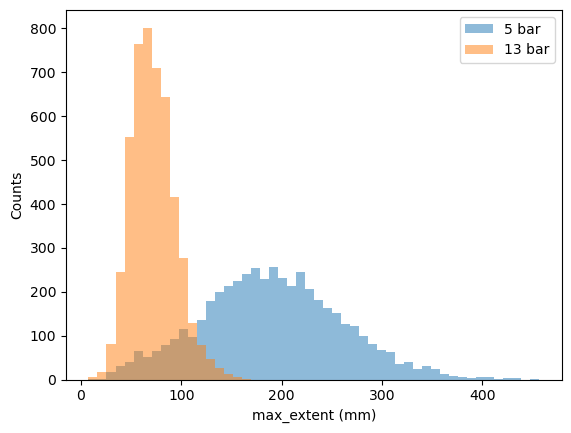

Median for 13 bar: 69.71954005346701
Median for 5 bar: 188.46942256779835


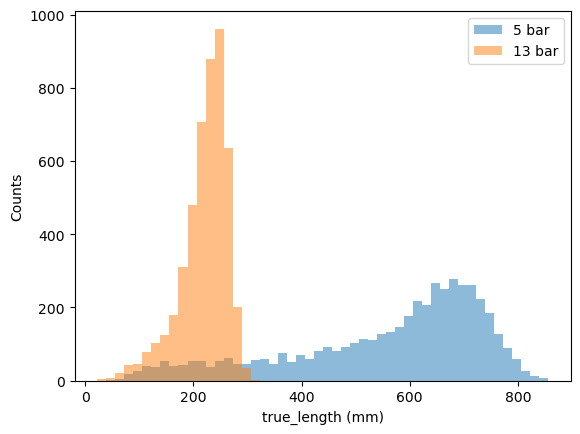

Median for 13 bar: 228.57342529296875
Median for 5 bar: 613.3433837890625


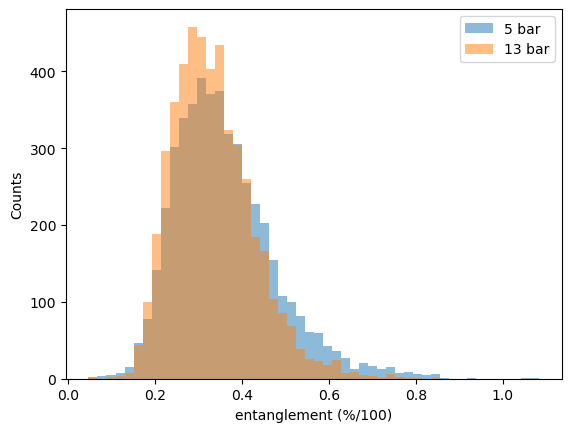

Median for 13 bar: 0.32125846535742947
Median for 5 bar: 0.34219719630015505


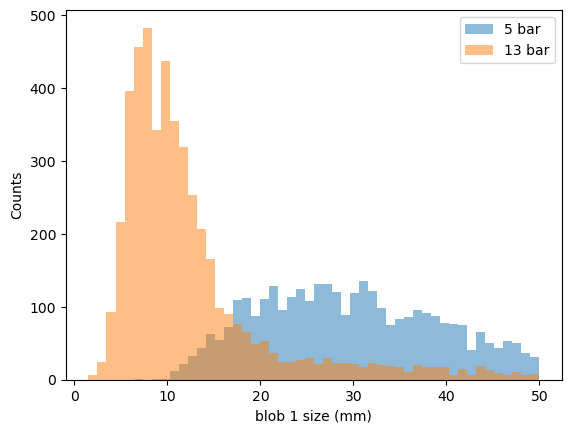

Median for 13 bar: 9.798994974874372
Median for 5 bar: 28.894472361809044


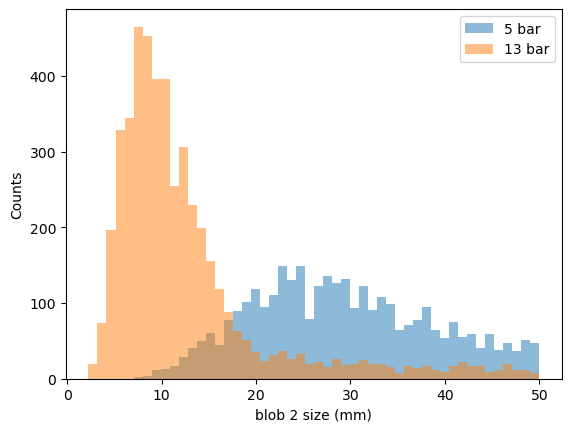

Median for 13 bar: 10.050251256281406
Median for 5 bar: 28.39195979899497


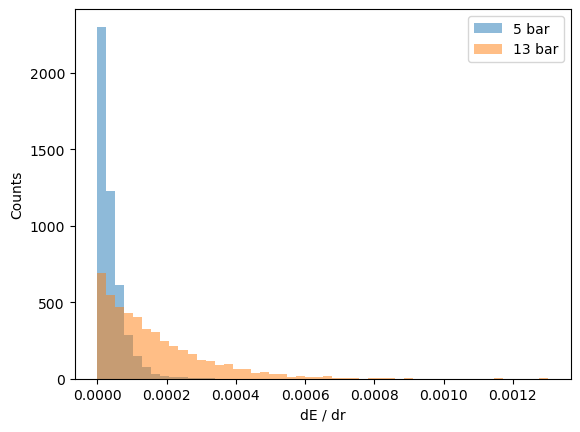

Median for 13 bar: 0.00012002842049696483
Median for 5 bar: 2.709051204874413e-05


In [28]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print_histos(dict_5bar, dict_13bar, key, str(label), abs = True)


# save and load

In [6]:
#import pickle

#with open('dict_5bar.pkl', 'wb') as f:
#    pickle.dump(dict_5bar, f)

#with open('dict_13bar.pkl', 'wb') as f:
#    pickle.dump(dict_13bar, f)

In [7]:
import pickle

# read in the pickles
with open('dict_5bar.pkl', 'rb') as f:
    dict_5bar = pickle.load(f)

with open('dict_13bar.pkl', 'rb') as f:
    dict_13bar = pickle.load(f)

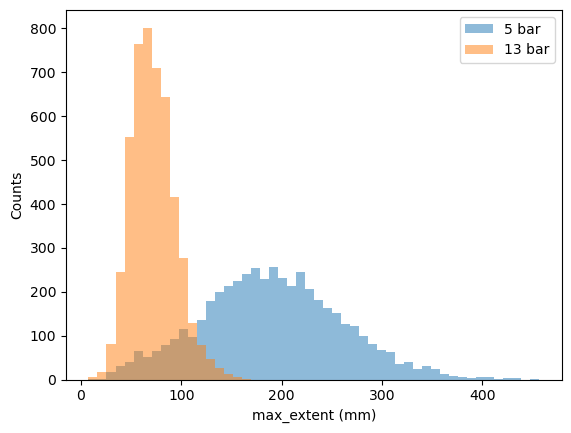

Median for 13 bar: 69.71954005346701
Median for 5 bar: 188.46942256779835
None


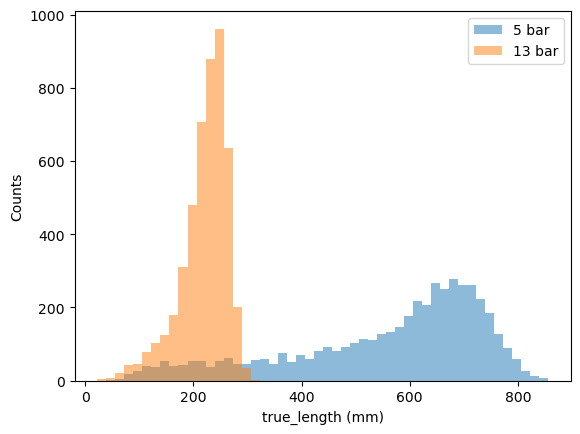

Median for 13 bar: 228.57342529296875
Median for 5 bar: 613.3433837890625
None


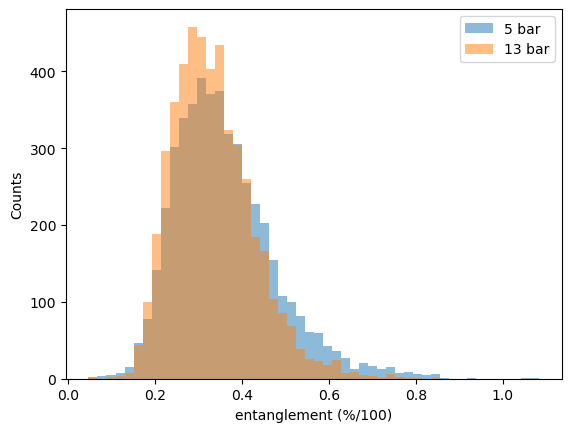

Median for 13 bar: 0.32125846535742947
Median for 5 bar: 0.34219719630015505
None


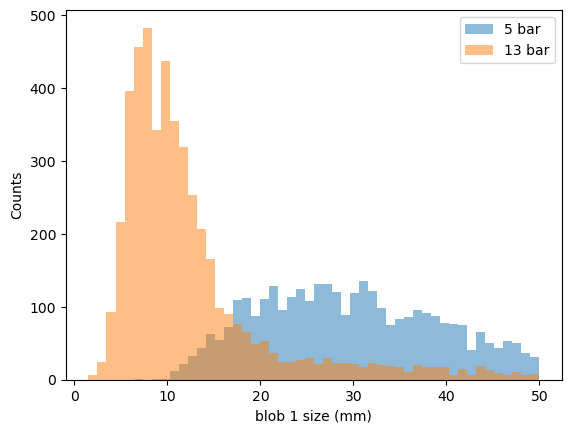

Median for 13 bar: 9.798994974874372
Median for 5 bar: 28.894472361809044
None


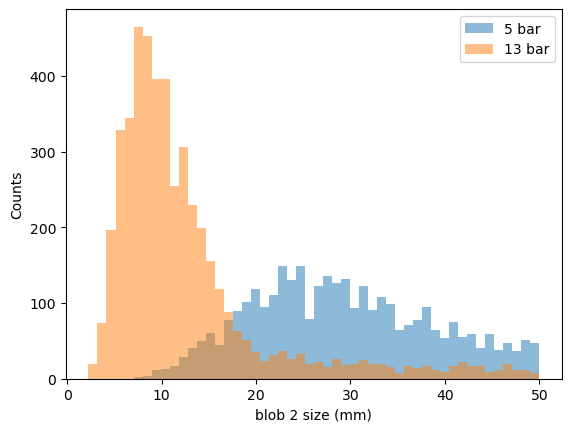

Median for 13 bar: 10.050251256281406
Median for 5 bar: 28.39195979899497
None


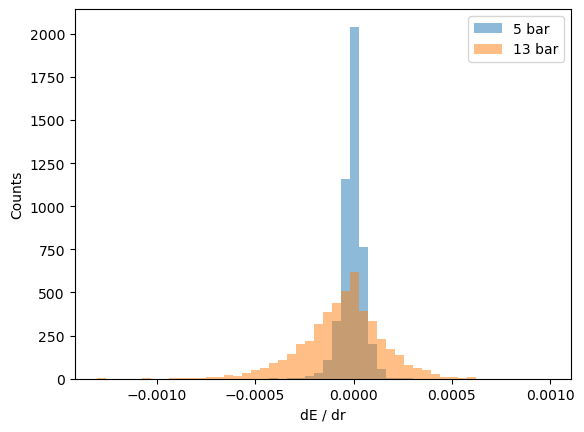

Median for 13 bar: -3.758834645850584e-05
Median for 5 bar: -3.4723256021607085e-06
None


In [29]:
x_labels_histo = ['max_extent (mm)', 'true_length (mm)', 'entanglement (%/100)', 'blob 1 size (mm)', 'blob 2 size (mm)', 'dE / dr']

for key, label in zip(dict_13bar.keys(), x_labels_histo):
    print(print_histos(dict_5bar, dict_13bar, key, str(label)))
